In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Menambahkan root proyek ke sys.path agar bisa diakses dari mana saja
project_root_path = Path.cwd().parent
if str(project_root_path) not in sys.path:
    sys.path.insert(0, str(project_root_path))
print(f"✅ Root proyek diatur ke: {project_root_path}")

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# === Path ke file output hasil analisis shifting ===
shift_result_path = project_root_path / "data/reports/state_shifts/all_state_shift_analysis.csv"

# === Path ke folder spektrum asli ===
spectrum_dir = project_root_path / "data/standarize/processed_spectrum"

if not shift_result_path.exists():
    raise FileNotFoundError("❌ File hasil shift tidak ditemukan. Jalankan state_correction.py --batch dulu.")


✅ Root proyek diatur ke: /home/acer/ai_spectrum_analysis_v2


In [24]:
shift_df = pd.read_csv(shift_result_path)
print(f"✅ Total data shift: {len(shift_df)} puncak")
print("Daftar file yang tersedia:")
display(shift_df["original_filename"].unique())


✅ Total data shift: 18877 puncak
Daftar file yang tersedia:


array(['529-34-0_IR_gas_0.jdx',
       '529-34-0_IR_LIQUID_(NEAT)_$$_PURITY_-_ANALYTICAL_1.jdx',
       '542-88-1_IR_SOLUTION_(10%_IN_CCl4_FOR_3800-1333,_10%_IN_CS2_FOR_1333-400_CM-1)_3.jdx',
       ...,
       '75-65-0_IR_GAS_(30_mmHg,_N2_ADDED,_TOTAL_PRESSURE_600_mmHg)_1.jdx',
       '75-65-0_IR_LIQUID_(NEAT)_3.jdx', 'IR_direct_298-04-4.jdx'],
      dtype=object)

In [25]:
shift_df = pd.read_csv(shift_result_path)
print(f"✅ Total data shift: {len(shift_df)} puncak")
print("Daftar file yang tersedia:")
display(shift_df["original_filename"].unique())



✅ Total data shift: 18877 puncak
Daftar file yang tersedia:


array(['529-34-0_IR_gas_0.jdx',
       '529-34-0_IR_LIQUID_(NEAT)_$$_PURITY_-_ANALYTICAL_1.jdx',
       '542-88-1_IR_SOLUTION_(10%_IN_CCl4_FOR_3800-1333,_10%_IN_CS2_FOR_1333-400_CM-1)_3.jdx',
       ...,
       '75-65-0_IR_GAS_(30_mmHg,_N2_ADDED,_TOTAL_PRESSURE_600_mmHg)_1.jdx',
       '75-65-0_IR_LIQUID_(NEAT)_3.jdx', 'IR_direct_298-04-4.jdx'],
      dtype=object)

In [26]:
# === Ganti nama ini sesuai dengan file yang kamu mau lihat ===
target_original_filename = "542-88-1_IR_VAPOR_(ABOUT_35_mmHg)_1.jdx"

# Ambil semua baris shift yang sesuai
shift_subset = shift_df[shift_df["original_filename"] == target_original_filename].copy()
if shift_subset.empty:
    raise ValueError(f"❌ Tidak ada data shift untuk file {target_original_filename}")

# Ambil rata-rata shift dari semua puncak di file ini
mean_shift = shift_subset["predicted_shift_cm-1"].mean()
std_shift = shift_subset["predicted_shift_cm-1"].std()
print(f"📊 Mean shift untuk {target_original_filename}: {mean_shift:.2f} ± {std_shift:.2f} cm⁻¹")


📊 Mean shift untuk 542-88-1_IR_VAPOR_(ABOUT_35_mmHg)_1.jdx: -5.00 ± 0.00 cm⁻¹


In [27]:
# Cari nama file yang sudah diproses di dalam direktori
# Skrip preprocess_universal.py mengubah 'namafile.jdx' menjadi 'IR_namafile.csv'
processed_stem = f"IR_{Path(target_original_filename).stem}"
try:
    # Cari file yang cocok di direktori spektrum
    spectrum_path = next(spectrum_dir.glob(f"{processed_stem}*.csv"))
except StopIteration:
    raise FileNotFoundError(f"❌ File spektrum yang diproses untuk '{target_original_filename}' tidak ditemukan di {spectrum_dir}")

print(f"✅ File spektrum ditemukan: {spectrum_path}")

if not spectrum_path.exists():
    raise FileNotFoundError(f"❌ File spektrum {spectrum_path} tidak ditemukan.")

spec_df = pd.read_csv(spectrum_path)
if not {"x_value", "y_value"}.issubset(spec_df.columns):
    raise ValueError("❌ File spektrum tidak memiliki kolom x_value, y_value")

wn = np.array(spec_df["x_value"])
inten = np.array(spec_df["y_value"])

✅ File spektrum ditemukan: /home/acer/ai_spectrum_analysis_v2/data/standarize/processed_spectrum/IR_542-88-1_IR_VAPOR_(ABOUT_35_mmHg)_1.csv


In [28]:
# Terapkan pergeseran berdasarkan rata-rata shift dari hasil analisis
wn_shifted = wn + mean_shift

# Normalisasi intensitas agar bisa dibandingkan
inten_norm = inten / np.max(inten)

# Buat versi bergeser (untuk visualisasi overlay)
inten_shifted = inten_norm.copy()


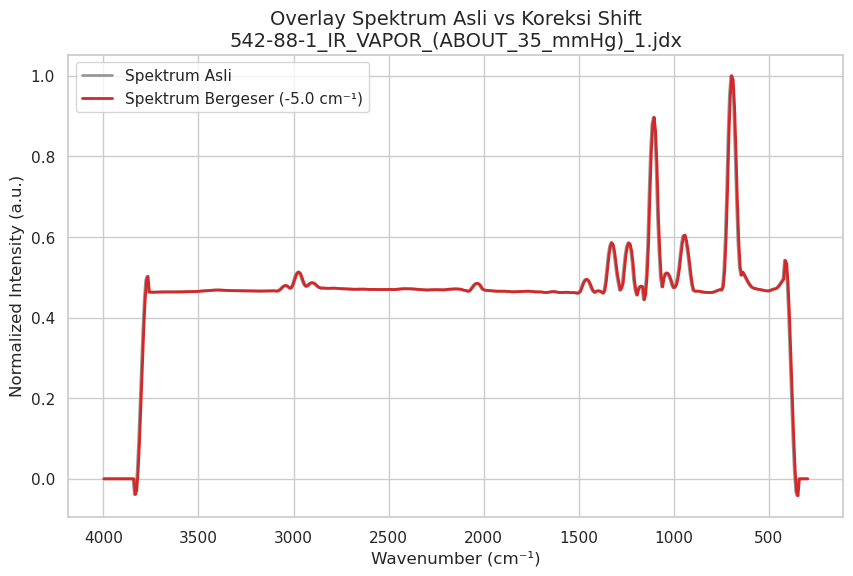

In [29]:
plt.figure(figsize=(10,6))

plt.plot(wn, inten_norm, label="Spektrum Asli", color="tab:gray", lw=2, alpha=0.8)
plt.plot(wn_shifted, inten_shifted, label=f"Spektrum Bergeser ({mean_shift:+.1f} cm⁻¹)", color="tab:red", lw=2)

plt.title(f"Overlay Spektrum Asli vs Koreksi Shift\n{target_original_filename}")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Normalized Intensity (a.u.)")
plt.gca().invert_xaxis()
plt.legend()
plt.show()


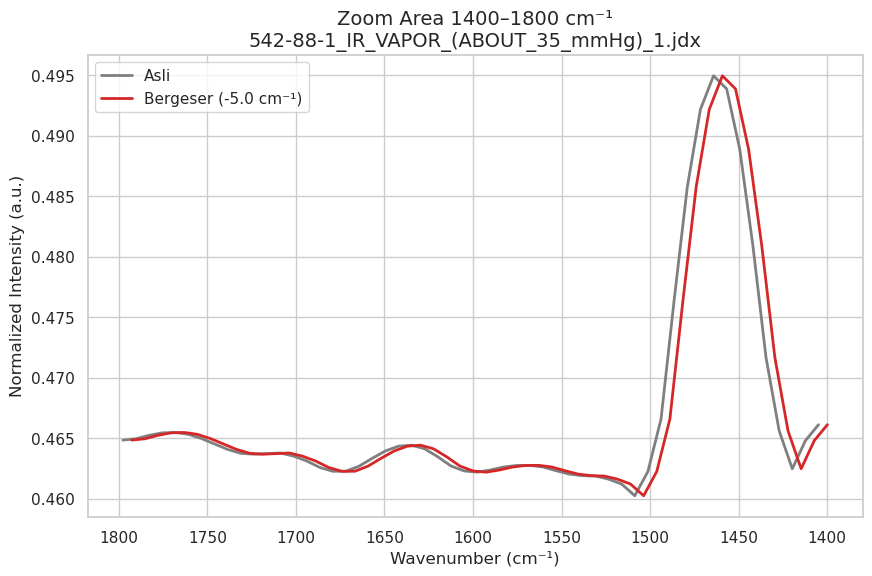

In [30]:
focus_range = (1400, 1800)

plt.figure(figsize=(10,6))
mask = (wn >= focus_range[0]) & (wn <= focus_range[1])

plt.plot(wn[mask], inten_norm[mask], label="Asli", color="tab:gray", lw=2)
plt.plot(wn_shifted[mask], inten_shifted[mask], label=f"Bergeser ({mean_shift:+.1f} cm⁻¹)", color="tab:red", lw=2)

plt.title(f"Zoom Area {focus_range[0]}–{focus_range[1]} cm⁻¹\n{target_original_filename}")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Normalized Intensity (a.u.)")
plt.gca().invert_xaxis()
plt.legend()
plt.show()

In [ ]:
output_dir = Path("data/reports/visualizations")
output_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(wn, inten_norm, label="Spektrum Asli", color="tab:gray", lw=2)
ax.plot(wn_shifted, inten_shifted, label=f"Bergeser ({mean_shift:+.1f} cm⁻¹)", color="tab:red", lw=2)
ax.set_title(f"Spektrum Asli vs Bergeser — {target_original_filename}")
ax.set_xlabel("Wavenumber (cm⁻¹)")
ax.set_ylabel("Normalized Intensity (a.u.)")
ax.invert_xaxis()
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / f"overlay_shift_{Path(target_original_filename).stem}.png", dpi=300)
print(f"📁 Grafik disimpan di: {output_dir}")
